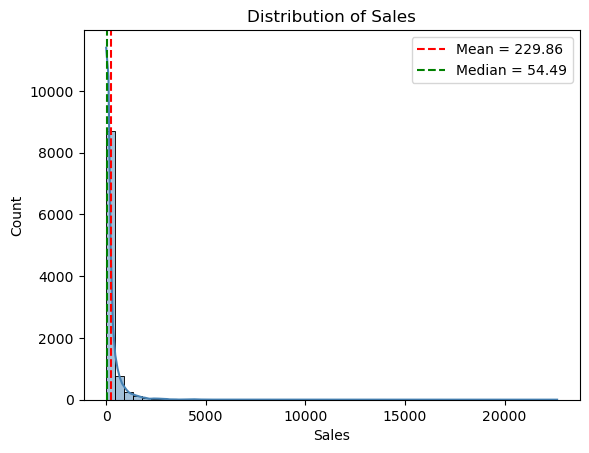

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
sales = data['Sales']

mean = sales.mean()
median = sales.median()
skewness = skew(sales)

sns.histplot(sales, kde=True, bins=50, color='steelblue')
plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
plt.axvline(median, color='green', linestyle='--', label=f'Median = {median:.2f}')
plt.title('Distribution of Sales')
plt.legend()
plt.show()
"""RIGHT SKEWED SO FEW LARGE ORDERS ADN SMALL PROFIT ORDERS ARE MORE SO MEDIAN IS MORE RELIABLE """

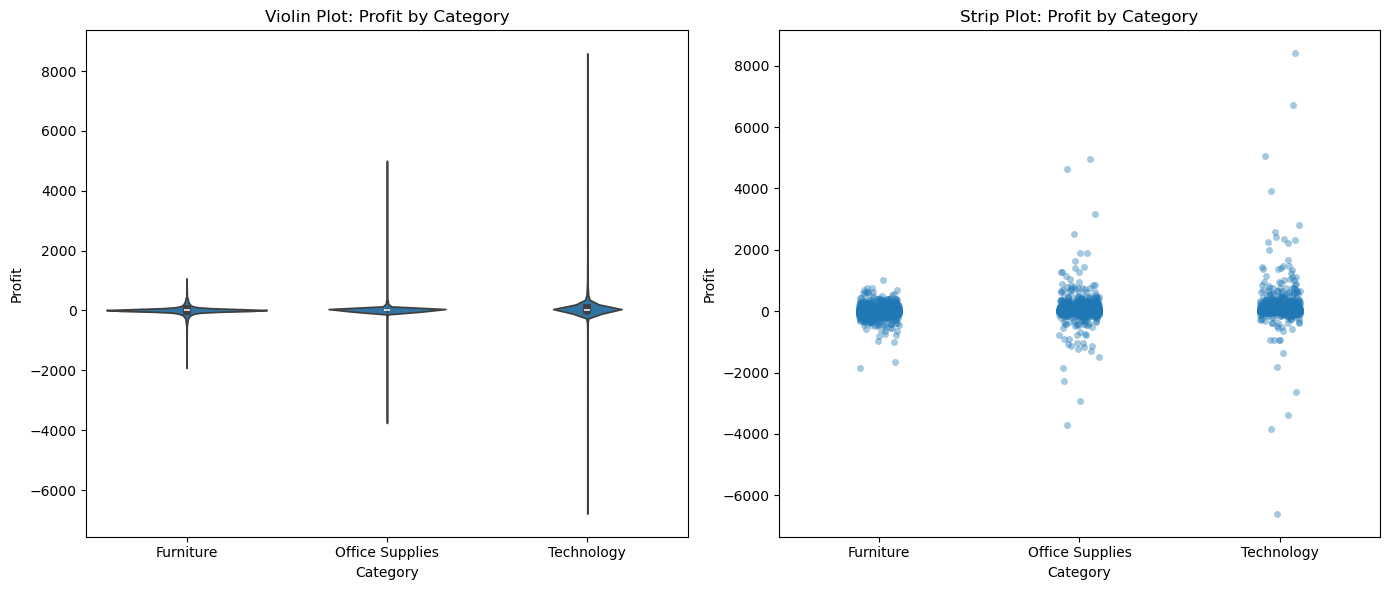

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=data, x='Category', y='Profit', ax=axes[0])
axes[0].set_title('Violin Plot: Profit by Category')

sns.stripplot(data=data, x='Category', y='Profit', jitter=True, alpha=0.4, ax=axes[1])
axes[1].set_title('Strip Plot: Profit by Category')

plt.tight_layout()
plt.show()

"""VIOLIN WINS -TECHNOLOGY VIOLIN IS VISIBLY WIDER WHILE OVERLAPPING STRIP POINTS OBSCURED"""

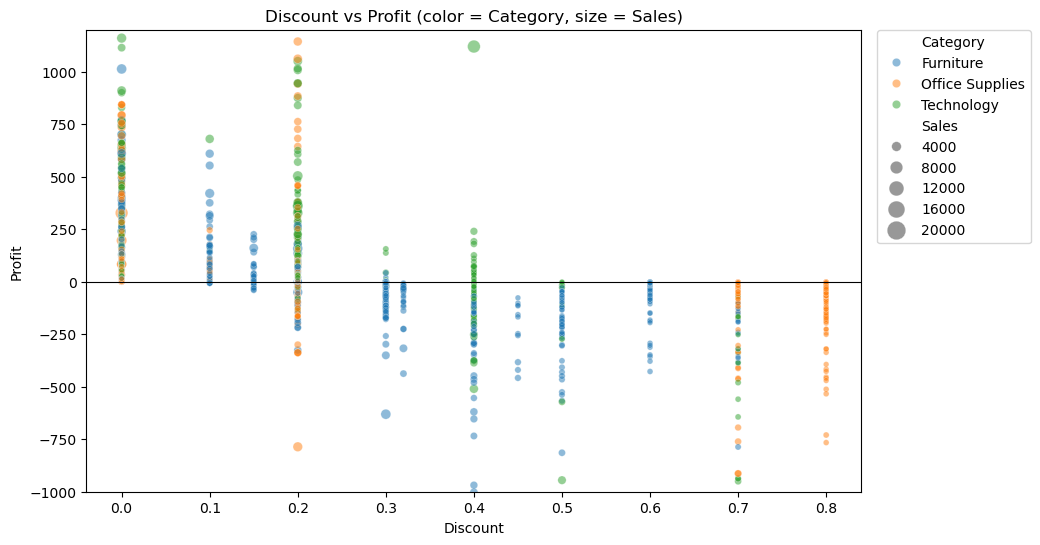

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='Discount',
    y='Profit',
    hue='Category',      
    size='Sales',        
    sizes=(15, 200),
    alpha=0.5,
    edgecolor='white',
    linewidth=0.3
)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylim(-1000, 1200)   
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title('Discount vs Profit (color = Category, size = Sales)')
plt.show()

In [13]:
import pandas as pd

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
numeric = data[['Sales', 'Quantity', 'Discount', 'Profit']]

pearson = numeric.corr(method='pearson')
spearman = numeric.corr(method='spearman')
"""PEARSON IS LINEAR RELATIONSHIP BTWEEN DISCOPUNT ADN PROFIT WHILE SPEARMAN ONLY SEES THE RELATION HERE MORE DSICPOUNT LEADS TO LESS PROIFIT"""

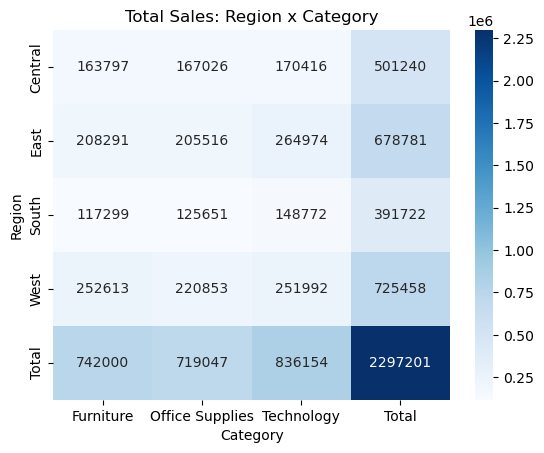

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

table = pd.pivot_table(
    data,
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)

sns.heatmap(table, annot=True, fmt='.0f', cmap='Blues')
plt.title('Total Sales: Region x Category')
plt.show()

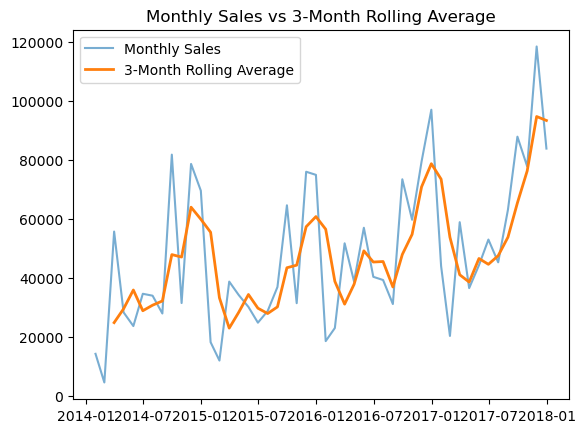

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
data['Order Date'] = pd.to_datetime(data['Order Date'])
data = data.set_index('Order Date')

monthly = data['Sales'].resample('ME').sum()
rolling = monthly.rolling(window=3).mean()

plt.plot(monthly, label='Monthly Sales', alpha=0.6)
plt.plot(rolling, label='3-Month Rolling Average', linewidth=2)
plt.legend()
plt.title('Monthly Sales vs 3-Month Rolling Average')
plt.show()

The raw monthly sales fluctuate significantly, making it difficult to identify the overall growth pattern. The rolling average reduces these fluctuations and highlights a clear upward trend, with sales generally reaching their highest levels around November and December each year.


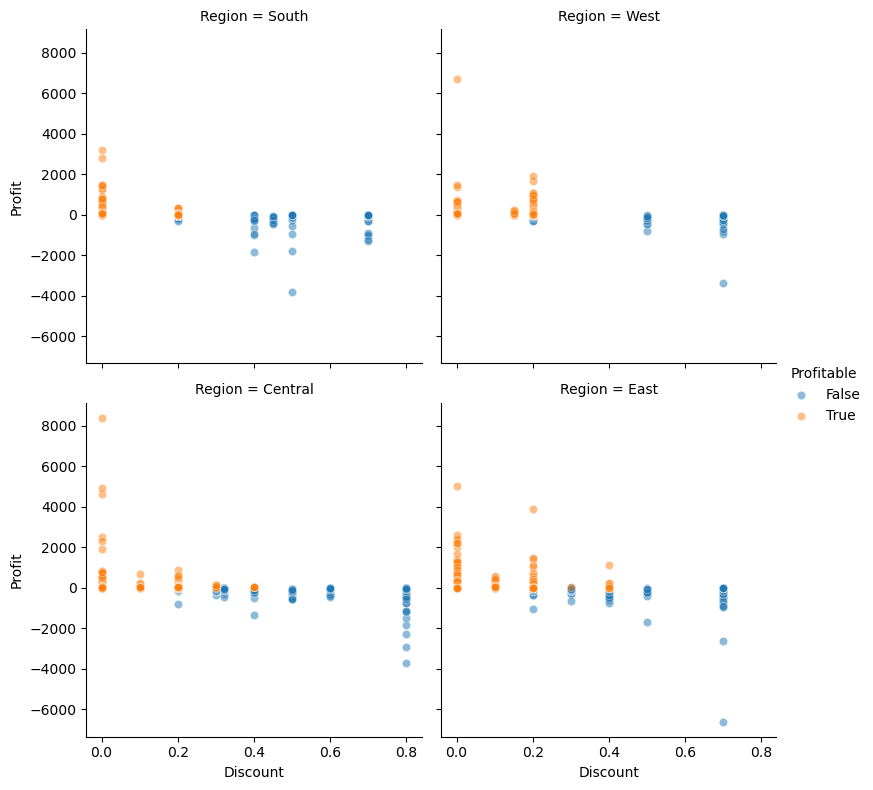

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
data['Profitable'] = data['Profit'] > 0

grid = sns.FacetGrid(data, col='Region', hue='Profitable', col_wrap=2, height=4)
grid.map(sns.scatterplot, 'Discount', 'Profit', alpha=0.5)
grid.add_legend()
plt.show()

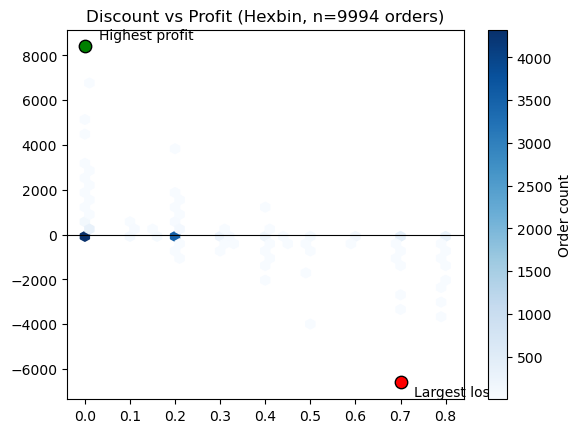

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

maxRow = data.loc[data['Profit'].idxmax()]
minRow = data.loc[data['Profit'].idxmin()]

hb = plt.hexbin(data['Discount'], data['Profit'], gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(hb, label='Order count')

plt.scatter(maxRow['Discount'], maxRow['Profit'], color='green', s=80, edgecolor='black')
plt.annotate('Highest profit', (maxRow['Discount'], maxRow['Profit']), xytext=(10, 5), textcoords='offset points')

plt.scatter(minRow['Discount'], minRow['Profit'], color='red', s=80, edgecolor='black')
plt.annotate('Largest loss', (minRow['Discount'], minRow['Profit']), xytext=(10, -10), textcoords='offset points')

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Discount vs Profit (Hexbin, n=9994 orders)')
plt.show()